In [1]:
import os, sys
os.environ["MPICH_GPU_SUPPORT_ENABLED"] = "0"
import random
import fitsio
import numpy as np
from astropy.table import Table,join,unique,vstack
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import ticker
from mockfactory import Catalog
import random

sys.path.append('../../')
from helper import REDSHIFT_BIN_LSS
%load_ext autoreload
%autoreload 2

from LSS.globals import main
import LSS.common_tools as common

outdir = '/pscratch/sd/s/shengyu/repeats/DA2/loa-v1'
OVERLEAF_DIR = '../../../overleaf/figures'
save_fig = True

def get_repeats(indat, labels = None):
    if labels is None:
        labels = ['Z']
    tids,cnts = np.unique(indat['TARGETID'],return_counts=True)
    rtids = tids[cnts>1]
    sel_r = np.isin(indat['TARGETID'],rtids)
    specflr = indat[sel_r]
    print("N rows with TARGETID repeated:", len(specflr))
    specflr.sort("TARGETID")
    out = {'TARGETID': []}
    for lab in labels:
        out[f'{lab}_1'] = []
        out[f'{lab}_2'] = []
    ind = 0
    n = len(specflr)
    while ind < n:
        row1 = specflr[ind]
        tid = row1['TARGETID']
        ind2 = 1
        while ind + ind2 < n and specflr[ind + ind2]['TARGETID'] == tid:
            row2 = specflr[ind + ind2]
            out['TARGETID'].append(tid)
            for lab in labels:
                out[f'{lab}_1'].append(row1[lab])
                out[f'{lab}_2'].append(row2[lab])
            ind2 += 1
        ind += ind2
        if ind % 100000 == 0:
            print("processed", ind)
    return Table(out)

In [ ]:
specf_all = []
rep_all = [] 
lss_all = []
specf_lss_all = []
tracers = ['BGS', 'LRG', 'ELG', 'QSO']

for tracer in tracers:
    # load the parent specf catalogs 
    specf = Catalog.read(outdir + f'/{tracer}_spec_zdone.fits')
    specf_all.append(specf)

    # load the repeats catalogs
    rep = Catalog.read(outdir+f'/{tracer}repeats_info.fits')
    zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
    lss_ids = np.load(f'/pscratch/sd/s/shengyu/repeats/DA2/loa-v1/{tracer}_target_ids.npy')
    sel_lss = np.isin(rep['TARGETID'], lss_ids)
    sel = np.isfinite(rep[f'{zcol}_1']) & np.isfinite(rep[f'{zcol}_2'])
    rep=rep[sel&sel_lss]
    rep_all.append(rep)

    path = '/dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP'
    if tracer =='BGS': tracer_label = 'BGS_BRIGHT-21.35'
    elif tracer == 'ELG': tracer_label = 'ELG_LOPnotqso'
    else: tracer_label = tracer
    lss_data = Catalog.read(path+f'/{tracer_label}_clustering.dat.fits')
    lss_all.append(lss_data)

    target_ids = np.load(f'/pscratch/sd/s/shengyu/repeats/DA2/loa-v1/{tracer}_target_ids.npy')
    sel_lss = np.isin(specf['TARGETID'], target_ids)
    specf_lss_all.append(specf[sel_lss])

In [17]:
for idx, tracer, specfsab, tr, lss, full in zip(range(len(tracers)), tracers, specf_all, repeat_all, lss_all, specf_lss_all):
    target_ids = np.load(f'/pscratch/sd/s/shengyu/repeats/DA2/loa-v1/{tracer}_target_ids.npy')
    print(f'{tracer} specf: {len(specfsab)}, repeats: {len(tr)}, target_ids: {len(target_ids)}, lss cat: {len(lss)}, specf in lss cat: {len(full)}')

BGS specf: 13038495, repeats: 55373, target_ids: 1616725, lss cat: 1616725, specf in lss cat: 1672098
LRG specf: 5874346, repeats: 209563, target_ids: 4934817, lss cat: 4934817, specf in lss cat: 5144380
ELG specf: 10570333, repeats: 459515, target_ids: 8889020, lss cat: 7482654, specf in lss cat: 9348535
QSO specf: 5105721, repeats: 1230704, target_ids: 2180571, lss cat: 2180571, specf in lss cat: 3427574


## PLOT

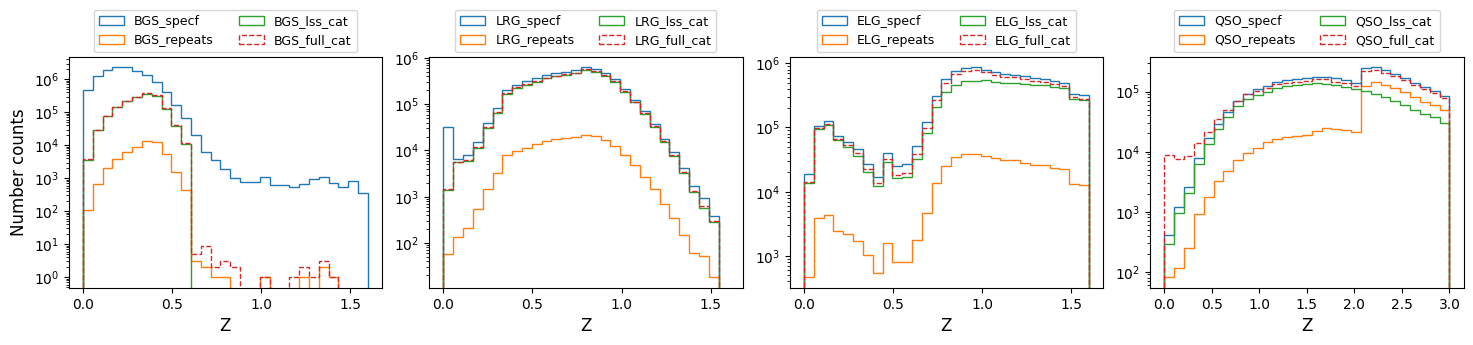

In [ ]:
tracers = ['BGS', 'LRG','ELG','QSO']

bin_range = [[0,1.6],[0,1.6],[0,1.6],[0,3]]
bins_num = 30

fig = plt.figure(figsize=(18, 3))
gs = gridspec.GridSpec(1,4,wspace=0.15,hspace=0.05)
for idx, tracer, specfsab, tr, lss, full in zip(range(len(tracers)), tracers, specf_all, repeat_all, lss_all, specf_lss_all):
    ax = plt.subplot(gs[idx])
    zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
    ax.hist(specfsab[zcol], bins = np.linspace(bin_range[idx][0], bin_range[idx][1], bins_num), histtype='step', label=f'{tracer}_specf')
    ax.hist(tr[f'{zcol}_1'], bins = np.linspace(bin_range[idx][0], bin_range[idx][1], bins_num), histtype='step', label=f'{tracer}_repeats')
    # ax.hist(tr[f'{zcol}_2'], bins=20, histtype='step', label=f'{tracer}_repeats_2')
    ax.hist(lss['Z'], bins=np.linspace(bin_range[idx][0], bin_range[idx][1], bins_num), histtype='step', label = f'{tracer}_lss_cat')
    ax.hist(full['Z'], bins=np.linspace(bin_range[idx][0], bin_range[idx][1], bins_num), histtype='step', label = f'{tracer}_full_cat', ls = '--')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.23), fontsize=9, ncol=2)
    # ax.legend(loc=1, fontsize=9)
    ax.set_xlabel('Z', fontsize=12)
    if idx == 0:
        ax.set_ylabel('Number counts', fontsize=12)
    ax.set_yscale('log')
    
if save_fig == True:
    plt.savefig(OVERLEAF_DIR+f'/hist_repeats_compare_Z', dpi=400, bbox_inches='tight')

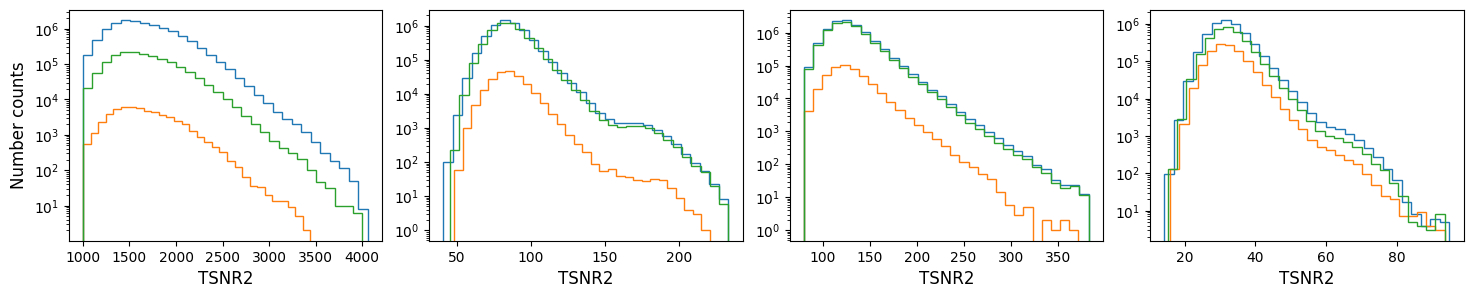

In [20]:
fig = plt.figure(figsize=(18, 3))
gs = gridspec.GridSpec(1,4,wspace=0.15,hspace=0.05)
for idx, tracer, specfsab, tr, lss, full in zip(range(len(tracers)), tracers, specf_all, repeat_all, lss_all, specf_lss_all):
    ax = plt.subplot(gs[idx])
    ax.hist(specfsab[f'TSNR2_{tracer}'], bins=30, histtype='step', label=f'{tracer}_specf')
    ax.hist(tr[f'TSNR2_{tracer}_1'], bins=30, histtype='step', label=f'{tracer}_repeats_1')
    # ax.hist(tr[f'TSNR2_{tracer}_2'], bins=30, histtype='step', label=f'{tracer}_repeats_2')
    ax.hist(full[f'TSNR2_{tracer}'], bins=30, histtype='step', label=f'{tracer}_full_cat', ls = '--')
    # ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), fontsize=11, ncol=3)
    # ax.legend(loc=1, fontsize=9)
    ax.set_xlabel('TSNR2', fontsize=12)
    if idx == 0:
        ax.set_ylabel('Number counts', fontsize=12)
    ax.set_yscale('log')
    
if save_fig == True:
    plt.savefig(OVERLEAF_DIR+f'/hist_repeats_compare_TNSR2', dpi=400, bbox_inches='tight')

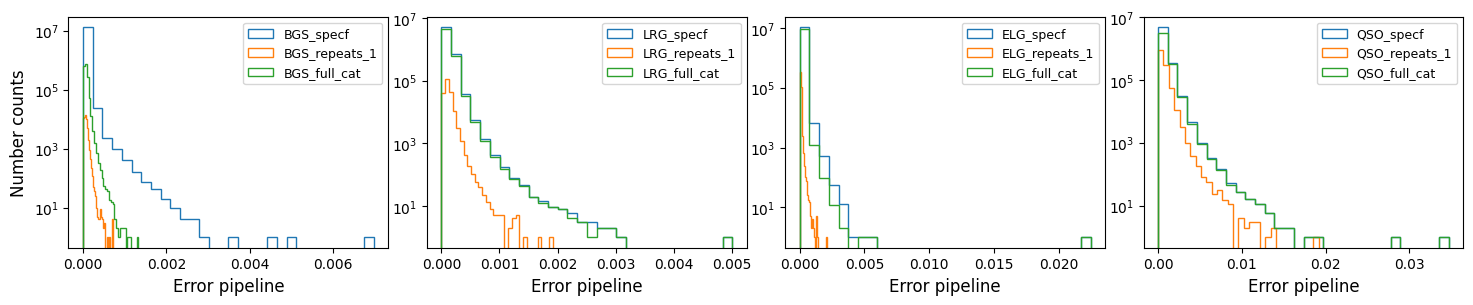

In [22]:
fig = plt.figure(figsize=(18, 3))
gs = gridspec.GridSpec(1,4,wspace=0.12,hspace=0.1)
for idx, tracer, specfsab, tr, lss, full in zip(range(len(tracers)), tracers, specf_all, repeat_all, lss_all, specf_lss_all):
    ax = plt.subplot(gs[idx])
    ax.hist(specfsab[f'ZERR'], bins=30, histtype='step', label=f'{tracer}_specf')
    ax.hist(tr[f'ZERR_1'], bins=30, histtype='step', label=f'{tracer}_repeats_1')
    # ax.hist(tr[f'ZERR_2'], bins=30, histtype='step', label=f'{tracer}_repeats_2')
    ax.hist(full[f'ZERR'], bins=30, histtype='step', label=f'{tracer}_full_cat')
    # ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), fontsize=11, ncol=3)
    ax.legend(loc=1, fontsize=9)
    ax.set_xlabel('Error pipeline', fontsize=12)
    if idx == 0:
        ax.set_ylabel('Number counts', fontsize=12)
    ax.set_yscale('log')
if save_fig == True:
    plt.savefig(OVERLEAF_DIR+f'/hist_repeats_compare_ZERR', dpi=400, bbox_inches='tight')

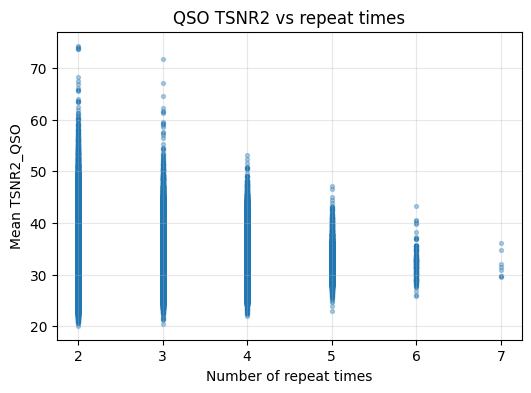

In [ ]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt

rep = Table.read("/pscratch/sd/s/shengyu/repeats/DA2/loa-v1/QSOrepeats_info.fits")
lss_ids = np.load(f"/pscratch/sd/s/shengyu/repeats/DA2/loa-v1/{tracer}_target_ids.npy")

sel_lss = np.isin(rep["TARGETID"], lss_ids)
sel = np.isfinite(rep[f"{zcol}_1"]) & np.isfinite(rep[f"{zcol}_2"])
rep = rep[sel & sel_lss]

targetid = np.asarray(rep["TARGETID"])
tsnr1 = np.asarray(rep["TSNR2_QSO_1"])
tsnr2 = np.asarray(rep["TSNR2_QSO_2"])

uniq_tid, first_idx, inverse, counts = np.unique(
    targetid,
    return_index=True,
    return_inverse=True,
    return_counts=True,
)

repeat_times = counts + 1
sum_tsnr2 = np.bincount(inverse, weights=tsnr2)

# mean over the unique observations for each object:
# first TSNR2_QSO_1 once + all TSNR2_QSO_2 values
tsnr2_mean = (tsnr1[first_idx] + sum_tsnr2) / repeat_times

plt.figure(figsize=(6, 4))
plt.scatter(repeat_times, tsnr2_mean, s=8, alpha=0.35)
plt.xlabel("Number of repeat times")
plt.ylabel("Mean TSNR2_QSO")
plt.title("QSO TSNR2 vs repeat times")
plt.grid(alpha=0.3)
plt.show()

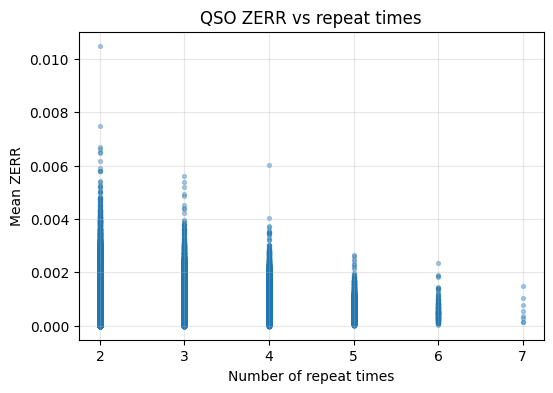

In [27]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt

rep = Table.read("/pscratch/sd/s/shengyu/repeats/DA2/loa-v1/QSOrepeats_info.fits")
lss_ids = np.load(f"/pscratch/sd/s/shengyu/repeats/DA2/loa-v1/{tracer}_target_ids.npy")

sel_lss = np.isin(rep["TARGETID"], lss_ids)
sel = np.isfinite(rep[f"{zcol}_1"]) & np.isfinite(rep[f"{zcol}_2"])
rep = rep[sel & sel_lss]

targetid = np.asarray(rep["TARGETID"])
tsnr1 = np.asarray(rep["ZERR_1"])
tsnr2 = np.asarray(rep["ZERR_2"])

uniq_tid, first_idx, inverse, counts = np.unique(
    targetid,
    return_index=True,
    return_inverse=True,
    return_counts=True,
)

repeat_times = counts + 1
sum_tsnr2 = np.bincount(inverse, weights=tsnr2)

# mean over the unique observations for each object:
# first TSNR2_QSO_1 once + all TSNR2_QSO_2 values
tsnr2_mean = (tsnr1[first_idx] + sum_tsnr2) / repeat_times

plt.figure(figsize=(6, 4))
plt.scatter(repeat_times, tsnr2_mean, s=8, alpha=0.35)
plt.xlabel("Number of repeat times")
plt.ylabel("Mean ZERR")
plt.title("QSO ZERR vs repeat times")
plt.grid(alpha=0.3)
plt.show()

## For dark tracers

In [11]:
survey = 'DA2'
time = 'dark'

mainp = main('LRG', 'loa-v1')#get settings for dark time

mt = mainp.mtld
tiles = mainp.tiles
imbits = mainp.imbits #mask bits applied to targeting
ebits = mainp.ebits #extra mask bits we think should be applied

tsnrcut = mainp.tsnrcut
dchi2 = mainp.dchi2
tnsrcol = mainp.tsnrcol        
zmin = mainp.zmin
zmax = mainp.zmax
badfib = mainp.badfib

#get set of tiles
wd = mt['SURVEY'] == 'main'
wd &= mt['ZDONE'] == 'true'
wd &= mt['FAPRGRM'] == time
if survey == 'Y1':
    wd &= mt['ZDATE'] < 20220900
if survey == 'DA2':
    wd &= mt['ZDATE'] < 20240410
mtld = mt[wd]

# for tracer
ldirspec = '/dvs_ro/cfs/cdirs/desi/survey/catalogs/'+f'{survey}'+'/LSS/'+'loa-v1'+'/'
specfo = ldirspec+f'datcomb_{time}_spec_zdone.fits'
specf = Table(fitsio.read(specfo))
sel = np.isin(specf['TILEID'],mtld['TILEID'])
specf = specf[sel]
specf = Table(specf)
specf.keep_columns(['TARGETID','Z','ZWARN','ZERR', 'DELTACHI2','LOCATION','DESI_TARGET','TILEID','TSNR2_LRG','TSNR2_ELG', 'TSNR2_QSO', 'ZWARN_MTL','COADD_FIBERSTATUS','FIBER','LASTNIGHT', 'Z_QN','Z_QN_CONF','IS_QSO_QN' ])
specf = common.cut_specdat(specf,badfib=mainp.badfib_td,tsnr_min=tsnrcut,tsnr_col=tnsrcol,fibstatusbits=mainp.badfib_status,remove_badfiber_spike_nz=True,mask_petal_nights=True)

LRG
number with no data 114111
number with bad qa 730556
number at low tsnr2 487520
will mask fibers with time dependence
number removed from time dependent mask is 411848
number removed from spike mask is 56226
number removed from petal night mask is 133031


In [13]:
specf

TARGETID,LASTNIGHT,Z,ZERR,ZWARN,DELTACHI2,LOCATION,FIBER,COADD_FIBERSTATUS,DESI_TARGET,TILEID,TSNR2_ELG,TSNR2_LRG,TSNR2_QSO,ZWARN_MTL,Z_QN,Z_QN_CONF,IS_QSO_QN
int64,int32,float64,float64,int64,float64,int64,int32,int32,int64,int32,float32,float32,float32,int64,float64,float64,int16
2204596575404032,20211207,0.9202842403601226,8.215467697228755e-05,4,6.247507736086845,7231,3696,0,4611686018427387904,5843,149.73386,100.694695,33.79132,4,2.1043300258932427,0.0011781915615822337,0
2204623473475584,20240109,0.18525533312667702,6.52643938379786e-05,4,0.6904128678143024,187,29,0,4611686018427387904,6271,110.81747,75.89079,27.704742,4,0.9887578312190795,7.508927148918077e-05,0
2204652607111168,20220309,0.016411489188294572,3.191587475369417e-05,0,24.80390017834725,7423,3771,0,4611686018427387904,10367,147.25053,93.63391,30.293745,0,1.7035186598092165,0.010176743245881605,0
2204698811564032,20221027,1.4071094922636993,0.00012600868959775256,4,0.7681537866592407,5227,2599,0,4611686018427387904,9492,128.25554,87.42097,30.562073,4,1.590997353036471,0.002710550342419712,0
2204712820539392,20220301,0.016040149651302335,2.3910465384871773e-05,0,22.177696721395478,3425,1767,0,4611686018427387904,2558,113.28457,78.879616,23.58123,0,1.6467931095079722,0.048941458323948105,0
2204728519819264,20211008,0.4540019230769707,6.778581023548571e-05,4,4.886444889008999,7087,3979,0,4611686018427387904,1154,113.35596,77.30165,31.76311,4,1.8195670332322287,0.0006004674747686866,0
2204728519819264,20230811,0.957850132167,9.628853805861223e-05,4,0.028908050036989152,234,32,0,4611686018427387904,10945,106.028465,77.431335,29.988216,4,2.1602167872918034,0.010017138502105413,0
2204739815079936,20220924,1.1776288678684068,0.0001110576993158109,4,1.889523059129715,2265,1338,0,4611686018427387904,11237,125.48263,84.69672,33.359737,4,1.932610405961769,0.4180600009749265,0
2204743308935168,20220306,0.03313254973460166,4.098895526668919e-05,0,10.253139491425827,9209,4911,0,4611686018427387904,2848,124.665565,81.85579,28.181976,0,1.7067155034256958,0.0039002353330136025,0


In [ ]:
tracer = 'LRG'
zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
labels = [zcol, f'TSNR2_{tracer}', 'TILEID', 'ZWARN', 'ZERR', 'DELTACHI2']

sel_LRG = (specf['DESI_TARGET']) & 1 > 0
sel_gz = common.goodz_infull('LRG',specf,zcol='Z')
specfl = specf[sel_LRG&sel_gz]

specfl.write(outdir+f'/{tracer}_spec_zdone.fits',overwrite=True)
# lrgr = Table.read(outdir+f'/{tracer}repeats_info.fits')
# lrgr = get_repeats(specfl,labels=labels)
# lrgr.write(outdir+f'/{tracer}repeats_info.fits',overwrite=True)

In [15]:
tracer = 'ELG'
zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
labels = [zcol, f'TSNR2_{tracer}', 'TILEID', 'ZWARN', 'ZERR', 'DELTACHI2']

elgf = fitsio.read(mainp.elgzf,columns=['TARGETID','LOCATION','TILEID','OII_FLUX','OII_FLUX_IVAR'])
specfe_ = join(specf,elgf,keys=['TARGETID','TILEID','LOCATION'],join_type='left')
o2c = np.log10(specfe_['OII_FLUX'] * np.sqrt(specfe_['OII_FLUX_IVAR']))+0.2*np.log10(specfe_['DELTACHI2'])
w = (o2c*0) != 0
w |= specfe_['OII_FLUX'] < 0
o2c[w] = -20
specfe_['o2c'] = o2c
sel_ELG = (specfe_['DESI_TARGET'] & 2) > 0
sel_gz = common.goodz_infull('ELG',specfe_,zcol='Z')
specfe = specfe_[sel_ELG&sel_gz]

specfe.write(outdir+f'/{tracer}_spec_zdone.fits',overwrite=True)

# elgr = Table.read(outdir+f'/{tracer}repeats_info.fits')
# elgr = get_repeats(specfe, labels=labels)
# elgr.write(outdir+f'/{tracer}repeats_info.fits',overwrite=True)

/tmp/ipykernel_1725527/2762312231.py:7: RuntimeWarning: divide by zero encountered in log10
  o2c = np.log10(specfe_['OII_FLUX'] * np.sqrt(specfe_['OII_FLUX_IVAR']))+0.2*np.log10(specfe_['DELTACHI2'])
/tmp/ipykernel_1725527/2762312231.py:7: RuntimeWarning: invalid value encountered in log10
  o2c = np.log10(specfe_['OII_FLUX'] * np.sqrt(specfe_['OII_FLUX_IVAR']))+0.2*np.log10(specfe_['DELTACHI2'])
/tmp/ipykernel_1725527/2762312231.py:8: RuntimeWarning: invalid value encountered in multiply
  w = (o2c*0) != 0


In [16]:
tracer = 'QSO'
zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
labels = [zcol, f'TSNR2_{tracer}', 'TILEID', 'ZWARN', 'ZERR', 'DELTACHI2']

qsof = fitsio.read(mainp.qsozf,columns=['TARGETID','LOCATION','TILEID','Z'])
specfq_ = join(specf,qsof,keys=['TARGETID','TILEID','LOCATION'],join_type='left',uniq_col_name='{col_name}{table_name}',table_names=['','_QF'])
selqso = specfq_['Z_QF']!=999999
selqso &= (specfq_['DESI_TARGET'] & 4) > 0
specfq = specfq_[selqso]

specfq.write(outdir+f'/{tracer}_spec_zdone.fits',overwrite=True)

# qsor = Table.read(outdir+f'/{tracer}repeats_info.fits')
# qsor = get_repeats(specfq, labels=labels)
# qsor.write(outdir+f'/{tracer}repeats_info.fits',overwrite=True)

## For bright tracers

In [17]:
survey = 'DA2'
time = 'bright'

mainp = main('BGS', 'loa-v1')#get settings for bright time

mt = mainp.mtld
tiles = mainp.tiles
imbits = mainp.imbits #mask bits applied to targeting
ebits = mainp.ebits #extra mask bits we think should be applied

tsnrcut = mainp.tsnrcut
dchi2 = mainp.dchi2
tnsrcol = mainp.tsnrcol        
zmin = mainp.zmin
zmax = mainp.zmax
badfib = mainp.badfib

#get set of tiles
wd = mt['SURVEY'] == 'main'
wd &= mt['ZDONE'] == 'true'
wd &= mt['FAPRGRM'] == time
if survey == 'Y1':
    wd &= mt['ZDATE'] < 20220900
if survey == 'DA2':
    wd &= mt['ZDATE'] < 20240410
mtld = mt[wd]

# for tracer
ldirspec = '/global/cfs/cdirs/desi/survey/catalogs/'+f'{survey}'+'/LSS/'+'loa-v1'+'/'
specfo_ = ldirspec+f'datcomb_{time}_spec_zdone.fits'
specf_ = Table(fitsio.read(specfo_.replace('global','dvs_ro')))
sel = np.isin(specf_['TILEID'],mtld['TILEID'])
specf_ = specf_[sel]
specf_ = Table(specf_)
# specf_.keep_columns(['TARGETID','Z','ZWARN','ZERR', 'DELTACHI2','LOCATION','BGS_TARGET','TILEID','TSNR2_BGS','TSNR2_ELG','ZWARN_MTL','COADD_FIBERSTATUS','FIBER','LASTNIGHT'])
specf_ = common.cut_specdat(specf_,badfib=mainp.badfib_td,tsnr_min=tsnrcut,tsnr_col=tnsrcol,fibstatusbits=mainp.badfib_status,remove_badfiber_spike_nz=True,mask_petal_nights=True)

BGS
number with no data 86136
number with bad qa 508781
number at low tsnr2 453265
will mask fibers with time dependence
number removed from time dependent mask is 317259
number removed from spike mask is 42775
number removed from petal night mask is 23826


In [18]:
mask = (specf_['TARGETID'] == 39627727757644552)
sel_BGS = specf_['BGS_TARGET'] > 0
specf_[mask&sel_BGS]

TARGETID,LASTNIGHT,Z,ZERR,ZWARN,CHI2,COEFF,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,LOCATION,FIBER,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,DESI_TARGET,BGS_TARGET,TILEID,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_PSF_TO_FIBER_SPECFLUX,TSNR2_BGS_B,TSNR2_ELG_B,TSNR2_LRG_B,TSNR2_LYA_B,TSNR2_QSO_B,TSNR2_BGS_R,TSNR2_ELG_R,TSNR2_LRG_R,TSNR2_LYA_R,TSNR2_QSO_R,TSNR2_BGS_Z,TSNR2_ELG_Z,TSNR2_LRG_Z,TSNR2_LYA_Z,TSNR2_QSO_Z,TSNR2_BGS,TSNR2_ELG,TSNR2_LRG,TSNR2_LYA,TSNR2_QSO,ZWARN_MTL,Z_QN,Z_QN_CONF,IS_QSO_QN
int64,int32,float64,float64,int64,float64,float64[10],int64,str6,str20,int64,float64,int64,int32,int32,float64,float64,float32,float32,int32,int64,int64,int32,int16,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float64,float64,int16
39627727757644552,20210603,0.28605946469628174,9.198213390713147e-06,0,8045.786234855652,143.2864882364516 .. -4.367489734044751,7928,GALAXY,,10,522.2704429626465,4378,2190,0,204.46622019151852,-2.5503565184912986,253.21628,250.50107,2000,1152921504606846976,65537,20120,2,964.9967,2,-0.0145,0.014713939,-0.003,0.005830952,0.7481759,127.86466,0.021860672,0.27160963,11.332578,0.51850194,966.18896,9.477605,14.202571,0.023305643,2.593621,1530.1909,29.322514,14.821446,0.0,5.65003,2624.2446,38.82198,29.295628,11.355884,8.762154,0,3.2964683614709323,0.46435915805572214,0
39627727757644552,20220314,1.6477375766567535,2.137333635345514e-05,0,8586.428625106812,1152.3566646141471 .. 41.8019101974451,7832,GALAXY,,10,191.55810737609863,6057,3323,0,204.46622019151852,-2.5503565184912986,-73.4424,125.3221,2,1152921504606846976,65537,23728,1,799.9182,1,0.01019535,0.01019535,-0.0011595977,0.0011595977,0.76974344,84.14863,0.014535021,0.16222425,10.792868,0.39138868,420.24655,5.4973283,7.429301,0.006210314,1.5307702,1070.4338,26.36167,11.431301,0.0,5.3412204,1574.829,31.873533,19.022827,10.799078,7.263379,0,1.2739415614305245,0.0012299088493887252,0


In [23]:
(specf_['DESI_TARGET']&60)==0

array([ True,  True,  True, ...,  True,  True,  True])

In [19]:
tracer = 'BGS'
zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
labels = [zcol, f'TSNR2_{tracer}', 'TILEID', 'ZWARN', 'ZERR', 'DELTACHI2']

sel_BGS = specf_['BGS_TARGET'] > 0
sel_gz = common.goodz_infull('BGS',specf_,zcol='Z')
specfb = specf_[sel_BGS&sel_gz]

specfb.write(outdir+f'/{tracer}_spec_zdone.fits',overwrite=True)

# bgsr = Table.read(outdir+f'/{tracer}repeats_info.fits')
# bgsr = get_repeats(specfb, labels=labels)
# bgsr.write(outdir+'/BGSrepeats_info.fits',overwrite=True)